# Analysis of the Gun Violence Dataset

# Part 1. &ndash; Problem Understanding & Data Understanding

Authors: Kacper Neumann, Stanisław Apanasiewicz, Jan Matusiak

----

## 1. The Dataset

### 1.1 General Information

The [Gun Violence Data](https://www.kaggle.com/datasets/jameslko/gun-violence-data) dataset contains detailed information about gun violence incidents in the United States, available in CSV format. It is based on records collected by the [Gun Violence Archive (GVA)](https://www.gunviolencearchive.org/), an independent organization created to provide a comprehensive database incidents in the U.S.

The CSV file contains data for all recorded gun violence incidents in the U.S. between January 2013 and March 2018.

In [1]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download('jameslko/gun-violence-data')
df = pd.read_csv(os.path.join(path, 'gun-violence-data_01-2013_03-2018.csv'))

/Users/janma/Desktop/gun-violence-analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 33.6M/33.6M [00:02<00:00, 13.5MB/s]

Extracting files...


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239677 entries, 0 to 239676
Data columns (total 29 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   incident_id                  239677 non-null  int64  
 1   date                         239677 non-null  str    
 2   state                        239677 non-null  str    
 3   city_or_county               239677 non-null  str    
 4   address                      223180 non-null  str    
 5   n_killed                     239677 non-null  int64  
 6   n_injured                    239677 non-null  int64  
 7   incident_url                 239677 non-null  str    
 8   source_url                   239209 non-null  str    
 9   incident_url_fields_missing  239677 non-null  bool   
 10  congressional_district       227733 non-null  float64
 11  gun_stolen                   140179 non-null  str    
 12  gun_type                     140226 non-null  str    
 13  incident_c

In [3]:
df['incident_id'].nunique()

239677

There are 239677 samples described with 29 attributes each. There are no duplicate rows.

In [4]:
df.set_index('incident_id', inplace=True)

In [5]:
missing_stats = pd.DataFrame({
    'column': df.columns,
    'n_missing': [df[col].isna().sum() for col in df.columns],
})
missing_stats['%_missing'] = (missing_stats['n_missing'] / df.shape[0]).apply(lambda x: f'{x:.0%}')
missing_stats

,column,n_missing,%_missing
0,date,0,0%
1,state,0,0%
2,city_or_county,0,0%
3,address,16497,7%
4,n_killed,0,0%
5,n_injured,0,0%
6,incident_url,0,0%
7,source_url,468,0%
8,incident_url_fields_missing,0,0%
9,congressional_district,11944,5%


### 1.2 Attributes

| Attribute | Type | Meaning | Unit / Format | Remarks |
|---|---|---|---|---|
| `incident_id` | Nominal | Unique identifier assigned to the incident | Positive integer ID |  |
| `date` | Ordinal | Date of the incident | Date in `YYYY-MM-DD` format |  |
| `state` | Nominal | U.S. state where the incident occurred | String |  |
| `city_or_county` | Nominal | City or county of the crime | String |  |
| `address` | Nominal | Address of the location | String | `NaN` for ~7% of rows |
| `n_killed` | Numerical | Number of people killed | Non-negative integer count |  |
| `n_injured` | Numerical | Number of people injured | Non-negative integer count |  |
| `incident_url` | Nominal | URL to the Gun Violence Archive incident page | URL string |  |
| `source_url` | Nominal | URL to the reporting source | URL string | `NaN` for <1% of rows |
| `incident_url_fields_missing` | Nominal | Flag indicating whether `incident_url` is missing | Boolean | Insignificant since `incident_url` is present in all rows, can be ignored |
| `congressional_district` | Nominal | ID of the congressional district connected to the location | Non-negative integer ID | `NaN` for ~5% of rows |
| `gun_stolen` | Nominal | Status of the guns used (e.g. `Stolen`) | Multi-valued string encoded as `index::status` pairs delimited by `\|\|` | `NaN` for ~42% of rows, missing mostly in the same rows as `gun_type`, requires preprocessing |
| `gun_type` | Nominal | Types of the guns used (e.g. `Handgun`) | Multi-valued string encoded as `index::type` pairs delimited by `\|\|` | `NaN` for ~41% of rows, missing in the same rows as `gun_stolen` and `n_guns_involved`, may be a specific firearm model or a more general category, requires preprocessing |
| `incident_characteristics` | Nominal | Details of the incident (e.g. victims, guns) | Multi-valued string delimited by `\|\|` | `NaN` in <1% of rows, some categories repeat across multiple thousands of rows while others are unique, requires preprocessing |
| `latitude` | Numerical | Geographic latitude | Degrees with 4-decimal points precision (float) | `NaN` for ~3% of rows, missing in the same rows as `longitude` |
| `location_description` | Nominal | Location details (e.g. name of the grocery store involved) | String | `NaN` for ~82% of rows, some categories repeat while others are unique, likely insignificant for further research |
| `longitude` | Numerical | Geographic longitude | Degrees with 4-decimal points precision (float) | `NaN` for ~3% of rows, missing in the same rows as `latitude` |
| `n_guns_involved` | Numerical | Number of guns involved | Positive integer count | `NaN` for ~41% of rows, missing in the same rows as `gun_type` |
| `notes` | Nominal | Additional information about the crime, may provide similar information to `incident_characteristics` | String | `NaN` for ~34% of rows, some values have similar structure but are mostly unique, may be difficult to preprocess |
| `participant_age` | Numerical | Age of the participants at the time of the incident | Multi-valued string encoded as `index::age` pairs delimited by `\|\|` | `NaN` for ~39% of rows, requires preprocessing |
| `participant_age_group` | Ordinal | Discretized `participant_age` (e.g. `Child 0-11`) | Multi-valued string encoded as `index::group` pairs delimited by `\|\|` | `NaN` for ~18% of rows, missing mostly in the same rows as `participant_age`, requires preprocessing |
| `participant_gender` | Nominal | Gender of the participants (`Male` / `Female`) | Multi-valued string encoded as `index::gender` pairs delimited by `\|\|` | `NaN` for ~15% of rows, requires preprocessing |
| `participant_name` | Nominal | Full name of the participants | Multi-valued string encoded as `index::name` pairs delimited by `\|\|` | `NaN` for ~51% of rows, requires preprocessing |
| `participant_relationship` | Nominal | Relationship between the participants (e.g. `Co-worker`) | Multi-valued string encoded as `index::relationship` pairs delimited by `\|\|` | `NaN` for ~93% of rows, likely insignificant for further reaserch |
| `participant_status` | Nominal | Status of the participants (e.g. `Killed`) | Multi-valued string encoded as `index::status` pairs delimited by `\|\|` | `NaN` for ~12% of rows, requires preprocessing |
| `participant_type` | Nominal | Type of the participants (e.g. `Victim`) | Multi-valued string encoded as `index::type` pairs delimited by `\|\|` | `NaN` for ~10% of rows, requires preprocessing |
| `sources` | Nominal | Similar to `source_url`, may include multiple sources | Multi-valued string of URLs delimited by `\|\|` | `NaN` for <1% of rows, requires preprocessing |
| `state_house_district` | Nominal | Voting house district | Positive integer ID | `NaN` for ~16% of rows, missing mostly in the same rows as `state_senate_district` |
| `state_senate_district` | Nominal | Voting senate district | Positive integer ID | `NaN` for ~13% of the datase, missing mostly in the same rows as `state_house_district` |

## 2. Data Mining Goals & Success Criteria

### 2.1 Goals

- Identify geographic and temporal hotspots of gun violence.
- Discover recurring incident patterns associated with higher severity.
- Compare incident patterns across jurisdictions.
- Summarize observable participant characteristics recorded in the dataset.
- Produce a structured feature set from the dataset’s multi-valued fields for downstream analysis.
- Build models to predict incident severity using available features.

### 2.2 Success Criteria

- The analysis produces interpretable hotspot and pattern findings that answer the project objectives.
- The preprocessing pipeline successfully converts multi-valued fields into usable features with limited information loss.
- Predictive models achieve a predefined performance threshold on a held-out test set.
- The analysis produces insights that are clear for a non-technical audience.

## 3. Exploratory Data Analysis

let's see at numerical attributes first

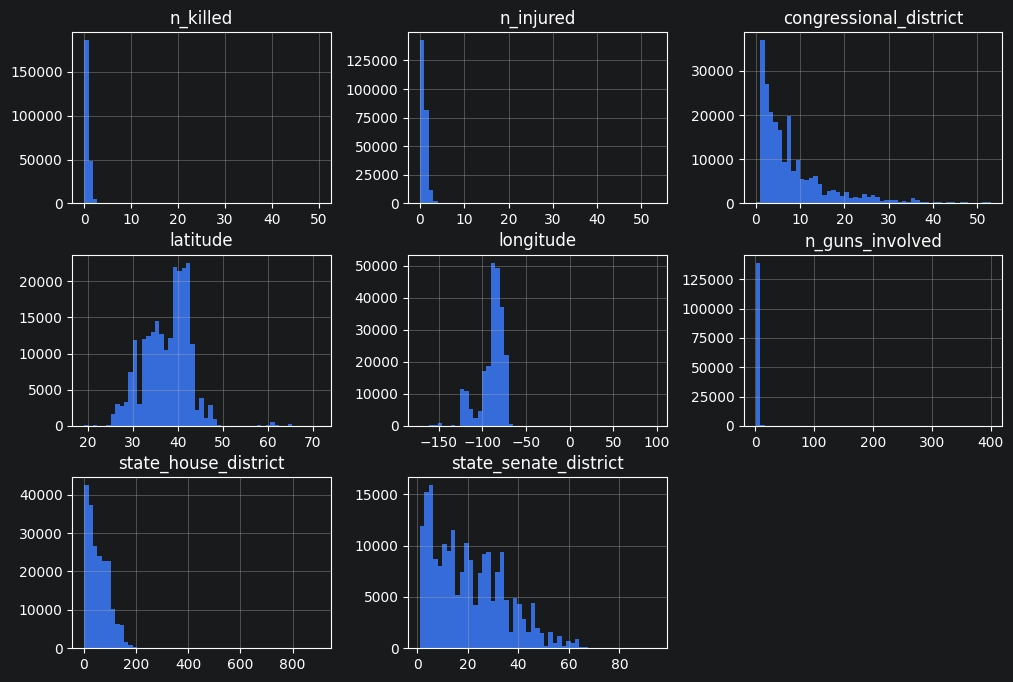

In [6]:
import matplotlib.pyplot as plt
df.hist(bins=53, figsize=(12, 8))

plt.show()

In [7]:

def plot_barplot(col):
    counts = col.value_counts()  

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(counts.index, counts.values, edgecolor='k', linewidth=0.3)

    ax.set_xlabel(col.name)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {col.name}")
    plt.xticks(rotation=45, ha='right')  
    plt.tight_layout()
    plt.show()

In [8]:
df.describe()

,n_killed,n_injured,congressional_district,latitude,longitude,n_guns_involved,state_house_district,state_senate_district
count,239677.000000,239677.000000,227733.000000,231754.000000,231754.000000,140226.000000,200905.000000,207342.00000
mean,0.252290,0.494007,8.001265,37.546598,-89.338348,1.372442,55.447132,20.47711
std,0.521779,0.729952,8.480835,5.130763,14.359546,4.678202,42.048117,14.20456
min,0.000000,0.000000,0.000000,19.111400,-171.429000,1.000000,1.000000,1.00000
25%,0.000000,0.000000,2.000000,33.903400,-94.158725,1.000000,21.000000,9.00000
50%,0.000000,0.000000,5.000000,38.570600,-86.249600,1.000000,47.000000,19.00000
75%,0.000000,1.000000,10.000000,41.437375,-80.048625,1.000000,84.000000,30.00000
max,50.000000,53.000000,53.000000,71.336800,97.433100,400.000000,901.000000,94.00000


the variables:
 'congressional_district' , 'state_senate_distict' and 'state_house_distict' 
 
 are integers, but they are assigned as a geographical divisions within a patricular state, so they need to be assigned to it. No point in seeing the correlation between them, they are actually categorical variables

it is also pointless to show latitude and longitude distributions separately, let's see a basic plot to see whether all of the data is in the within the USA

<Axes: xlabel='longitude', ylabel='latitude'>

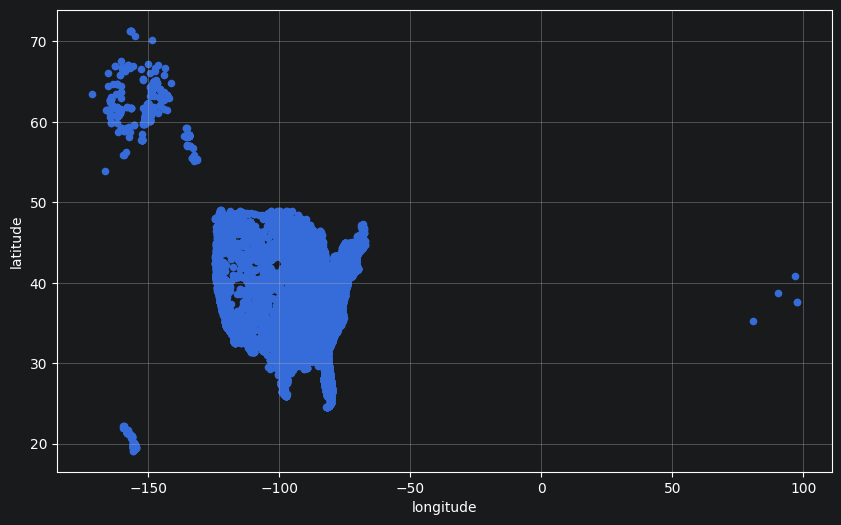

In [9]:
df.plot(x='longitude', y='latitude', kind='scatter', grid=True, figsize=(10, 6))

we can see 4 clusters here, the main USA land and Alaska can be seen very clearly. A cluster in a bottom left corner are Hawaii islands, it is also self explanatory. But the 4 dots at the right side of a plot are not that obvious.

In [10]:
pd.set_option('display.max_columns', None)
not_usa = df.loc[df['longitude']>0]
not_usa.head(10)
#nun = not_usa.to_numpy()
#print(nun)


,date,state,city_or_county,address,n_killed,n_injured,incident_url,source_url,incident_url_fields_missing,congressional_district,gun_stolen,gun_type,incident_characteristics,latitude,location_description,longitude,n_guns_involved,notes,participant_age,participant_age_group,participant_gender,participant_name,participant_relationship,participant_status,participant_type,sources,state_house_district,state_senate_district
incident_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
989590,2017-11-15,Missouri,St Louis,NaN,0,0,http://www.gunviolencearchive.org/incident/989590,http://stlouis.cbslocal.com/2017/11/15/update-...,False,NaN,0::Unknown,0::9mm,Non-Shooting Incident||TSA Action,38.7487,NaN,90.3700,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://stlouis.cbslocal.com/2017/11/15/update-...,NaN,NaN
1012331,2017-12-22,North Carolina,Charlotte,NaN,0,0,http://www.gunviolencearchive.org/incident/101...,http://wlos.com/news/local/tsa-seizes-another-...,False,NaN,0::Unknown,0::38 Spl,Non-Shooting Incident||TSA Action,35.2137,NaN,80.9491,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://wlos.com/news/local/tsa-seizes-another-...,NaN,NaN
1075419,2018-03-20,Nebraska,Lincoln,NaN,0,0,http://www.gunviolencearchive.org/incident/107...,http://www.1011now.com/content/news/Handgun-fo...,False,NaN,0::Unknown,0::Handgun,Non-Shooting Incident||TSA Action,40.8509,NaN,96.7591,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.1011now.com/content/news/Handgun-fo...,NaN,NaN
1081194,2018-03-25,Kansas,Wichita,NaN,0,0,http://www.gunviolencearchive.org/incident/108...,http://www.kansas.com/news/local/crime/article...,False,NaN,0::Unknown,0::38 Spl,Non-Shooting Incident||TSA Action,37.6499,NaN,97.4331,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.kansas.com/news/local/crime/article...,NaN,NaN
1081193,2018-03-29,Kansas,Wichita,NaN,0,0,http://www.gunviolencearchive.org/incident/108...,http://www.kansas.com/news/local/crime/article...,False,NaN,0::Unknown,0::9mm,Non-Shooting Incident||TSA Action,37.6499,NaN,97.4331,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.kansas.com/news/local/crime/article...,NaN,NaN


It seems that these dots symbolise actually 5 events. They are all non shooting incidents and are classified as 'TSA Action'. These events describe incidents at airports and they all have little to no data describing them. We've looked at the coordinates in https://www.gps-coordinates.net/. All of these places are located in western part of China, but these places are random and do not point to anything.

*TSA -> Transportation Security Administration - an agency of the United States Department of Homeland Security (DHS) that has authority over the security of transportation systems within and connecting to the United States. It was created as a response to the September 11 attacks to improve airport security.

okay, we can see that someone who imputed this data made a mistake. These longitudes should be negative numbers, but they have been written as positive ones. If we take (-1 * longitude) we actually get places of airports stated in data. We can correct this data with confidence.


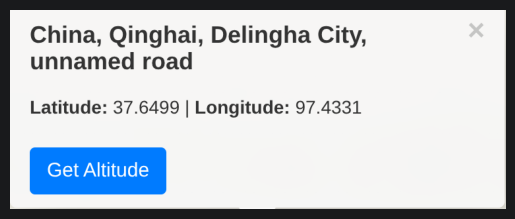

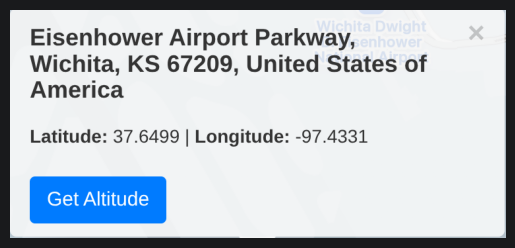

In [11]:
import matplotlib.image as mpimg

img1 = mpimg.imread('wrong_latitude.png')
plt.imshow(img1)
plt.axis('off') 
plt.show()
img2 = mpimg.imread('corrected_latitude.png')
plt.imshow(img2)
plt.axis('off')
plt.show()

In [12]:
df['longitude'] = df['longitude'].apply(lambda x: -x if x > 0 else x)

<Axes: xlabel='longitude', ylabel='latitude'>

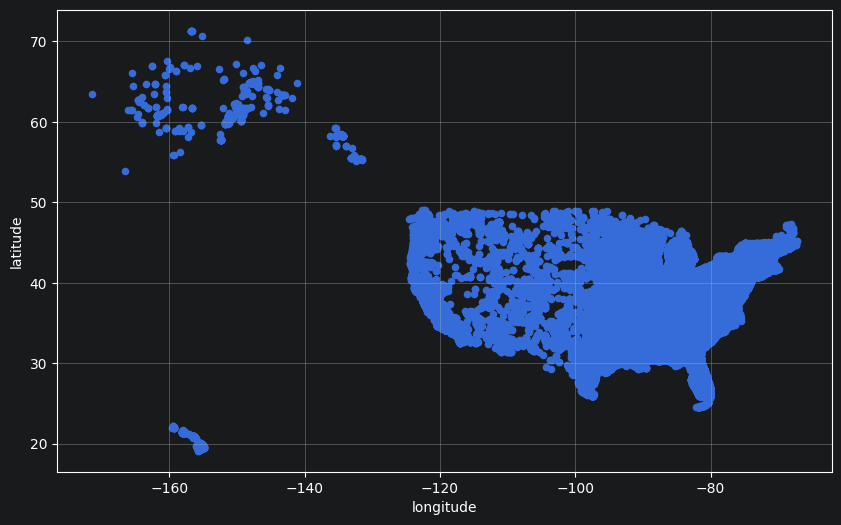

In [13]:
df.plot(x='longitude', y='latitude', kind='scatter', grid=True, figsize=(10, 6))

In [14]:

def catplot(x_col, y_col, hue_col):
    mask = x_col.notna() & y_col.notna()
    x = x_col[mask]
    y = y_col[mask]
    hue = hue_col[mask]

    fig, ax = plt.subplots(figsize=(18, 10))

    for category in hue.unique():
        mask_cat = hue == category
        ax.scatter(x[mask_cat], y[mask_cat], label=category, alpha=0.6,
                   edgecolors='k', linewidths=0.3)

    ax.set_xlabel(x_col.name)
    ax.set_ylabel(y_col.name)
    ax.set_title(f"{x_col.name} vs {y_col.name}")
    #ax.legend(title=hue_col.name)
    plt.tight_layout()
    plt.show()

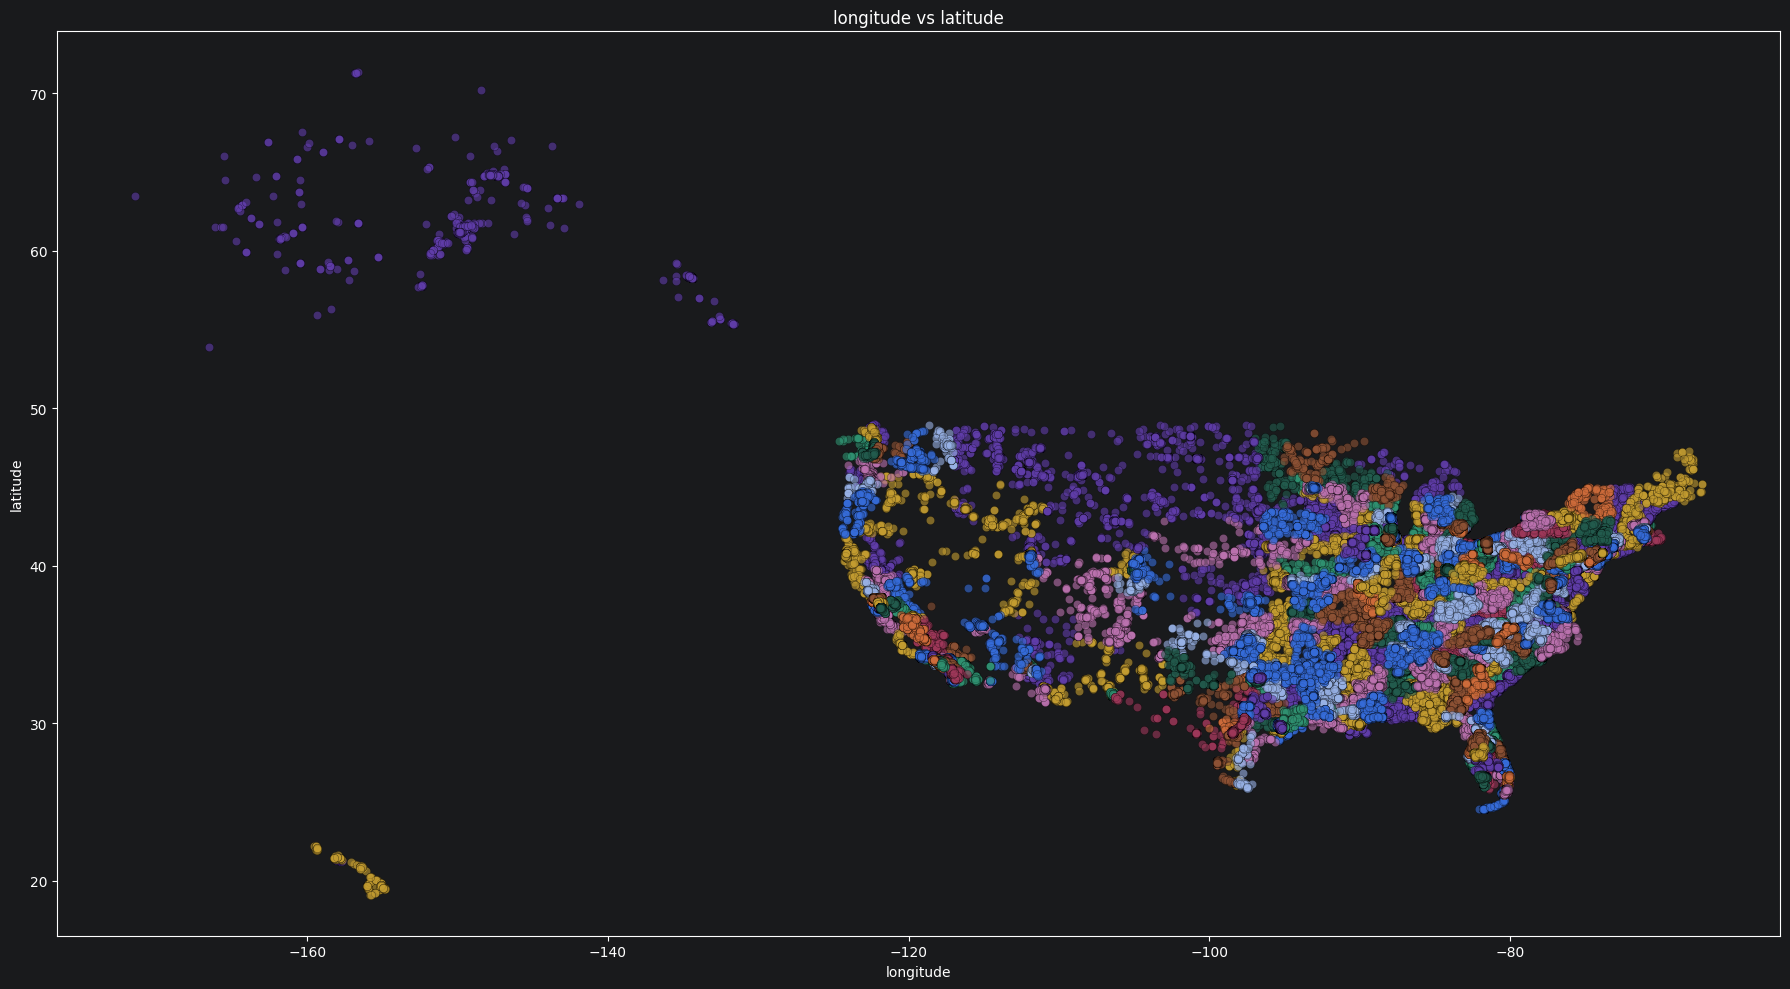

In [15]:
catplot(df['longitude'], df['latitude'], df['congressional_district'])

now the plot looks better, lets look at other numerical variables

In [16]:
df.describe()

,n_killed,n_injured,congressional_district,latitude,longitude,n_guns_involved,state_house_district,state_senate_district
count,239677.000000,239677.000000,227733.000000,231754.000000,231754.000000,140226.000000,200905.000000,207342.00000
mean,0.252290,0.494007,8.001265,37.546598,-89.342343,1.372442,55.447132,20.47711
std,0.521779,0.729952,8.480835,5.130763,14.334668,4.678202,42.048117,14.20456
min,0.000000,0.000000,0.000000,19.111400,-171.429000,1.000000,1.000000,1.00000
25%,0.000000,0.000000,2.000000,33.903400,-94.159175,1.000000,21.000000,9.00000
50%,0.000000,0.000000,5.000000,38.570600,-86.249650,1.000000,47.000000,19.00000
75%,0.000000,1.000000,10.000000,41.437375,-80.048975,1.000000,84.000000,30.00000
max,50.000000,53.000000,53.000000,71.336800,-67.271100,400.000000,901.000000,94.00000


co

In [17]:

def linreg(x_col, y_col):
    mask = x_col.notna() & y_col.notna()
    x = x_col[mask]
    y = y_col[mask]

    corr = x.corr(y)   # Pearson r

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.5, edgecolors='k', linewidths=0.3)
    plt.xlabel(x_col.name)
    plt.ylabel(y_col.name)
    plt.title(f"{x_col.name} vs {y_col.name}")
    plt.text(
        0.05, 0.95, f"r = {corr:.3f}",
        transform=plt.gca().transAxes, va='top', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    plt.tight_layout()
    plt.show()

    print(f"Pearson r : {corr:.4f}")

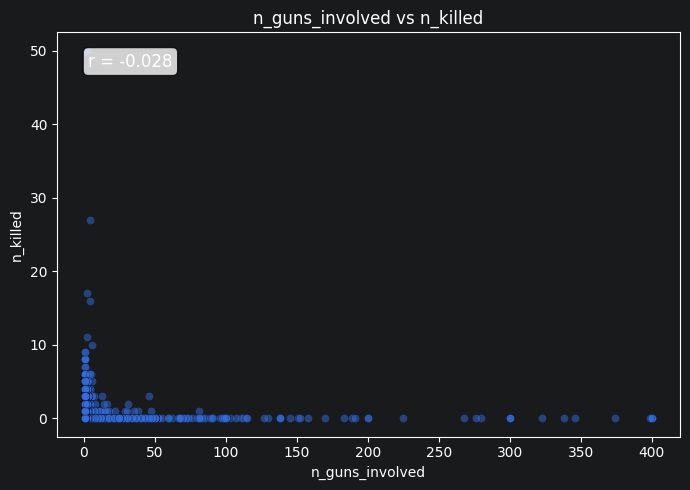

Pearson r : -0.0282


In [18]:
linreg(df['n_guns_involved'], df['n_killed'])

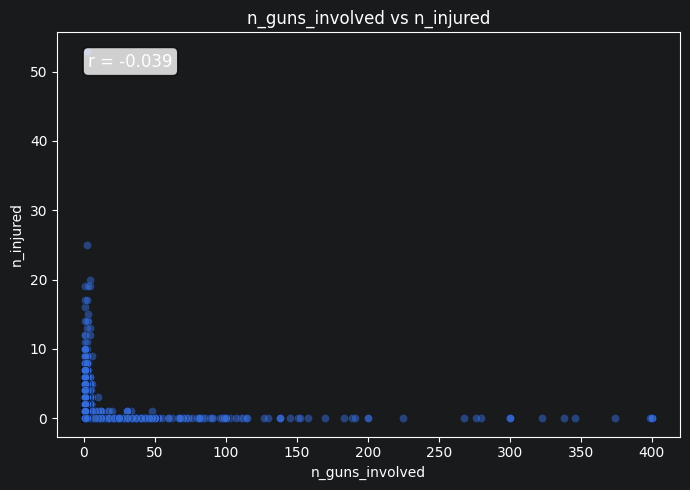

Pearson r : -0.0388


In [19]:
linreg(df['n_guns_involved'], df['n_injured'])

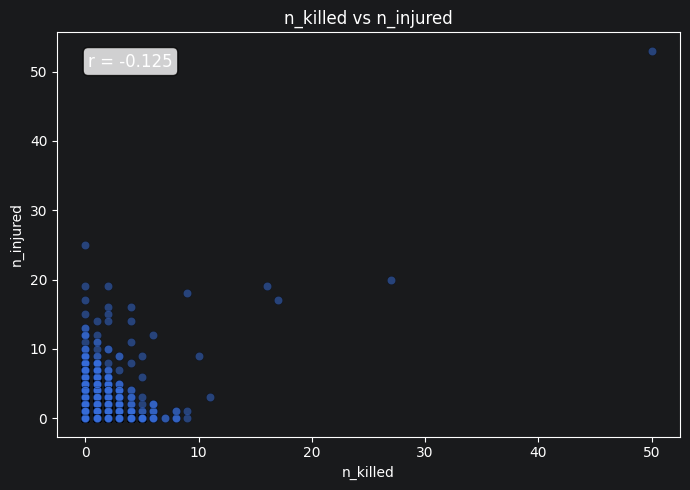

Pearson r : -0.1254


In [20]:
linreg(df['n_killed'], df['n_injured'])

the numerical data are hardly correlated

In [21]:
df['date'] = pd.to_datetime(df['date'])  
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

In [22]:
df['year'].value_counts()

year
2017    61401
2016    58763
2015    53579
2014    51854
2018    13802
2013      278
Name: count, dtype: int64

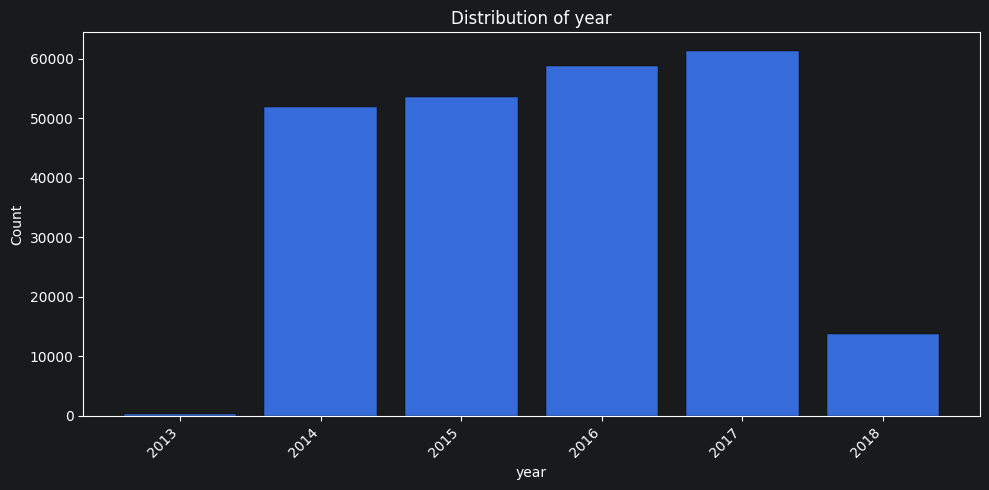

In [23]:
plot_barplot(df['year'])

the dataframe hold info from 01-01-2013 till 31-03-2018, it seems that in 2013 the murders were not reported into our dataframe. It seems to be some trend that the number of gun violence rises, however it is hard to tell because of non reported incidents in 2013.

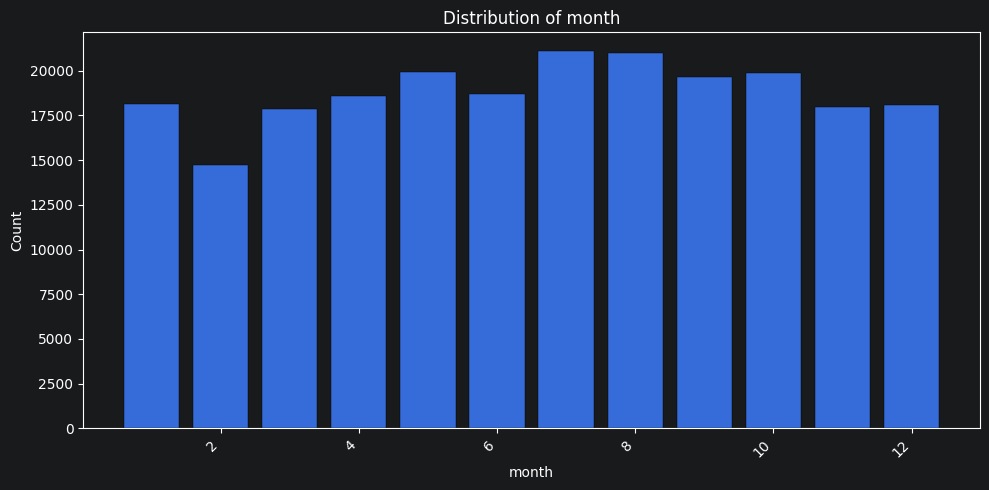

In [24]:
months_years = df[['month', 'year']]
months_years = months_years.loc[months_years['year'] > 2013]
months_years = months_years.loc[months_years['year'] < 2018]
plot_barplot(months_years['month'])

We dropped info from 2013 because it was incomplete and from 2018 because it contains only 3 months. We can see that a little more gun violence incidents happen in the summer. However, it is not that much of a difference.

In [25]:
def parse_column(df, col):
    rows = []
    for idx, row in df.iterrows():
        cell = row[col]
        if pd.isna(cell) or cell == '':
            continue

        for part in str(cell).split('||'):
            if '::' not in part:
                continue
            position, value = part.split('::')
            rows.append({
                'original_index': idx,
                'position': int(position),
                'value':    int(value)
            })

    return pd.DataFrame(rows) 



In [26]:
age_parsed = parse_column(df, 'participant_age')

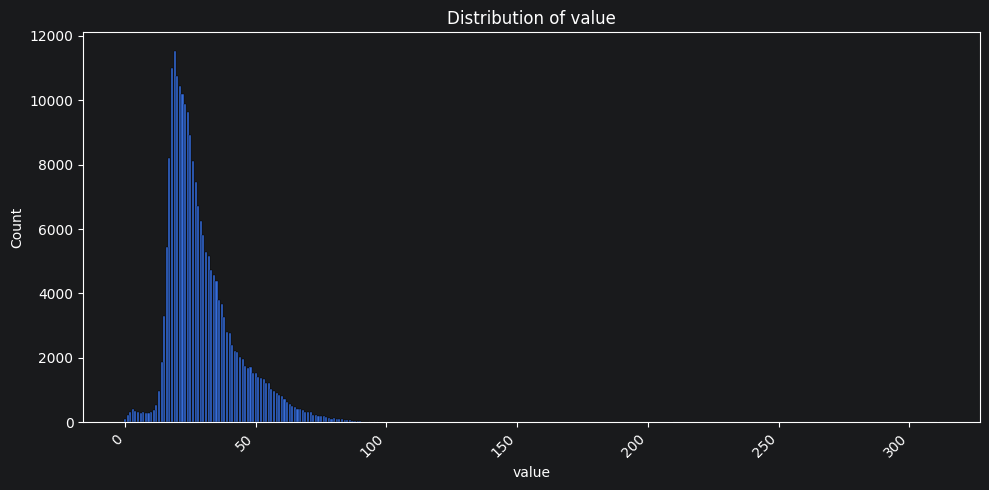

In [27]:
plot_barplot(age_parsed['value'])

In [28]:
age_parsed['value'].value_counts()

value
19     11535
18     11012
20     10741
21     10449
22     10195
       ...  
97         2
98         1
100        1
209        1
311        1
Name: count, Length: 104, dtype: int64

When we wanted to make a barplot for age of the criminals, we can see that it contains a mistake. Age 209 and 311

In [29]:
df.loc[1001184]

date                                                         2017-12-03 00:00:00
state                                                                     Kansas
city_or_county                                                            Holton
address                                                             802 Ohio Ave
n_killed                                                                       0
n_injured                                                                      0
incident_url                   http://www.gunviolencearchive.org/incident/100...
source_url                     http://cjonline.com/news/crime-courts/local/20...
incident_url_fields_missing                                                False
congressional_district                                                       2.0
gun_stolen                                                            0::Unknown
gun_type                                                              0::Unknown
incident_characteristics    

In [30]:
age_parsed = age_parsed.loc[age_parsed['value'] < 120]
#no one lives that long

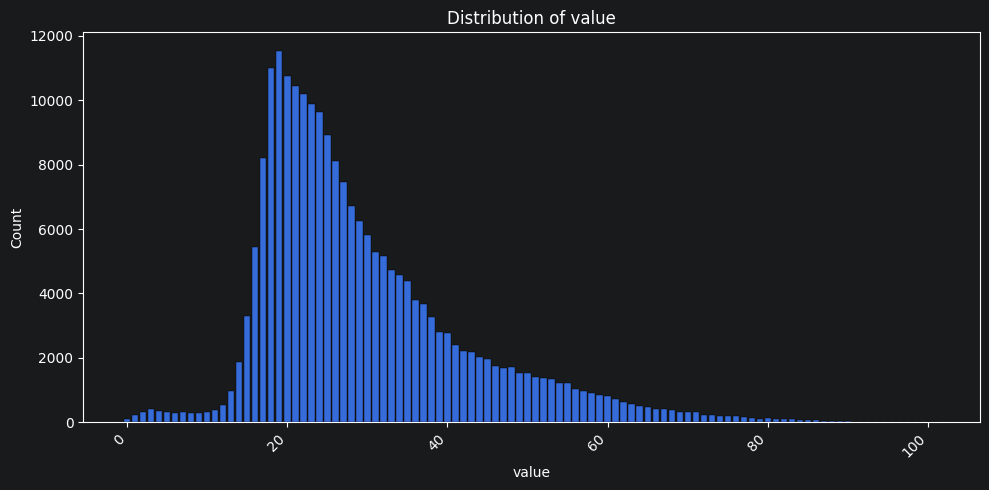

In [31]:
plot_barplot(age_parsed['value'])

we can see that most people in a shootings are in their late teens and early twenties, then the number declines with age

# 4. Discussion of Data Quality

Let's inspect key numerical attributes first. `latitude` and `longitude` were already validated and corrected in the previous section, so here we focus on count-based variables (`n_guns_involved`, `n_killed`, `n_injured`) by checking for invalid values (negative or non-integer) and plotting their distributions.

n_guns_involved:
  negative values: 0
  non-integer values: 0
  maximum value: 400.0


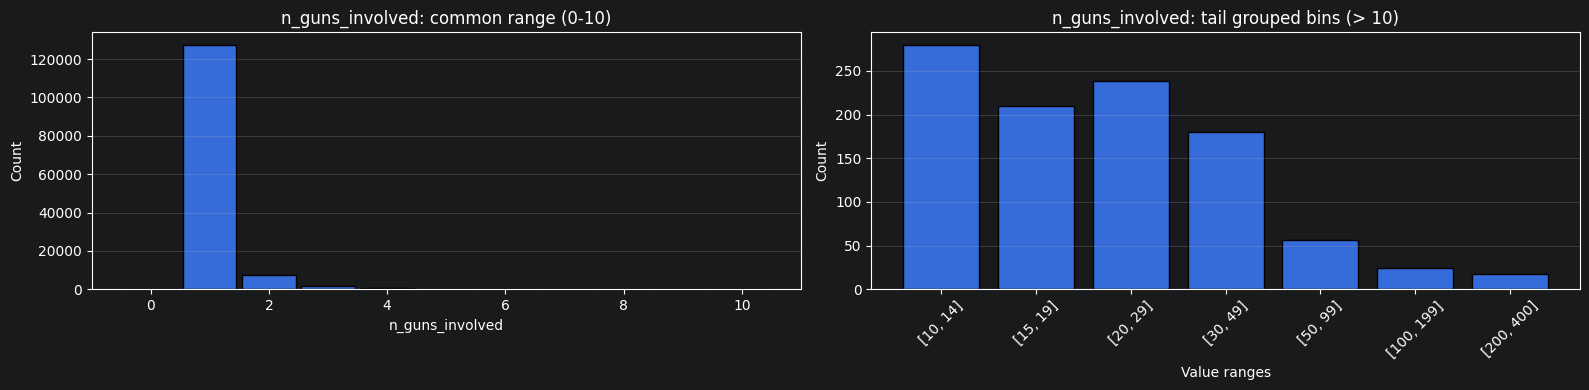

n_killed:
  negative values: 0
  non-integer values: 0
  maximum value: 50


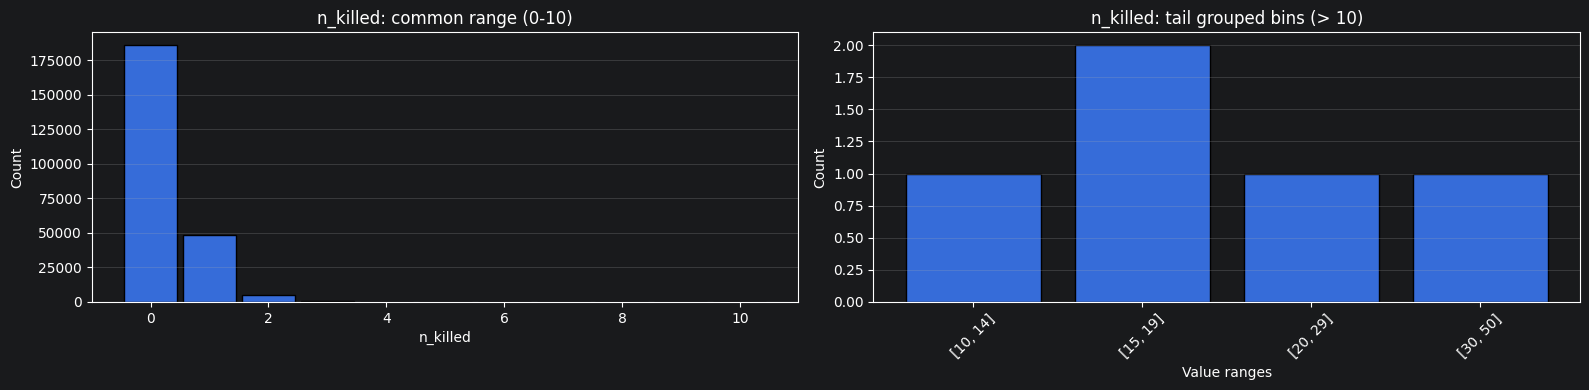

n_injured:
  negative values: 0
  non-integer values: 0
  maximum value: 53


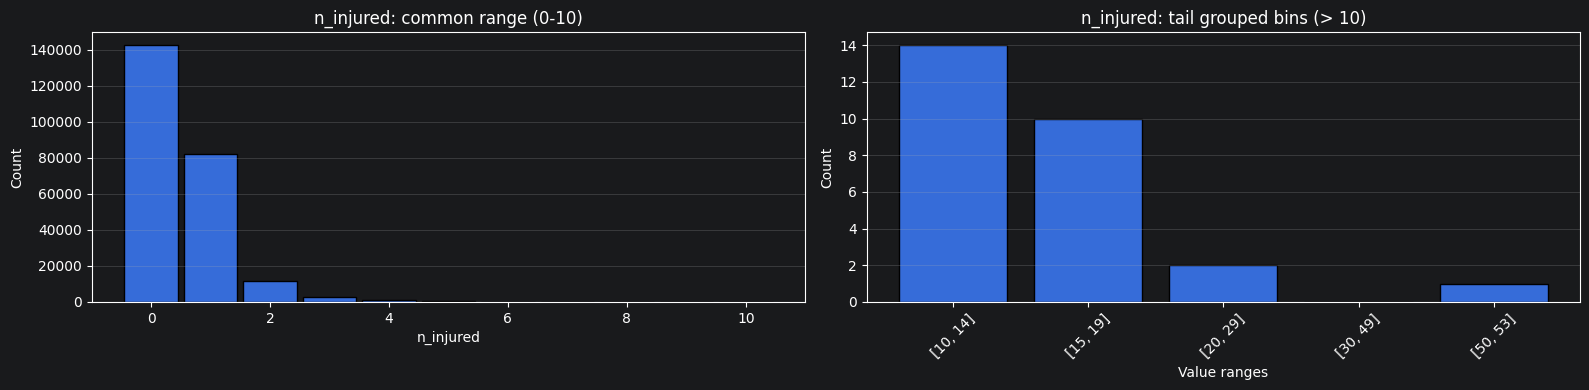

In [48]:
numerical_cols = ['n_guns_involved', 'n_killed', 'n_injured']
common_max = {'n_guns_involved': 10, 'n_killed': 10, 'n_injured': 10}

for col in numerical_cols:
    raw_s = df[col].dropna()
    s = raw_s.astype(int)
    cutoff = common_max[col]

    negative_count = (raw_s < 0).sum()
    non_integer_count = ((raw_s % 1) != 0).sum()
    max_value = raw_s.max()

    print(f"{col}:")
    print(f"  negative values: {negative_count}")
    print(f"  non-integer values: {non_integer_count}")
    print(f"  maximum value: {max_value}")

    counts = s.value_counts().sort_index()
    common_counts = counts.reindex(range(0, cutoff + 1), fill_value=0)
    tail_values = s[s > cutoff]

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    axes[0].bar(common_counts.index, common_counts.values, edgecolor='black', width=0.9)
    axes[0].set_title(f'{col}: common range (0-{cutoff})')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[0].grid(axis='y', alpha=0.3)

    if tail_values.empty:
        axes[1].text(0.5, 0.5, f'No values > {cutoff}', ha='center', va='center')
        axes[1].set_title(f'{col}: tail grouped bins (> {cutoff})')
        axes[1].set_xticks([])
        axes[1].set_yticks([])
    else:
        max_tail = int(tail_values.max())
        candidate_edges = [cutoff, 15, 20, 30, 50, 100, 200, 500, 1000]
        edges = sorted(set([cutoff] + [e for e in candidate_edges if cutoff < e < max_tail] + [max_tail + 1]))
        tail_bins = pd.cut(tail_values, bins=edges, right=False)
        tail_counts = tail_bins.value_counts().sort_index()
        labels = [f'[{int(interval.left)}, {int(interval.right) - 1}]' for interval in tail_counts.index]
        axes[1].bar(labels, tail_counts.values, edgecolor='black')
        axes[1].set_title(f'{col}: tail grouped bins (> {cutoff})')
        axes[1].set_xlabel('Value ranges')
        axes[1].set_ylabel('Count')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

There are no invalid values among these attributes. Outliers in these columns will not be handled, as for these attributes, a large value may be possible.

Now let's validate date values by extracting year/month/day and checking whether each date string is a valid calendar date (e.g., `YYYY-MM-DD`, no impossible combinations like June 31).

In [50]:
date_col = df['date']

if pd.api.types.is_datetime64_any_dtype(date_col):
    # If dates were already converted earlier in the notebook, reuse them.
    date_parsed = pd.to_datetime(date_col, errors='coerce')
    date_str = date_parsed.dt.strftime('%Y-%m-%d')
    bad_format_mask = pd.Series(False, index=df.index)
else:
    date_str = date_col.astype(str).str.strip()
    # Strict parsing: invalid format or impossible date combinations become NaT.
    date_parsed = pd.to_datetime(date_str, format='%Y-%m-%d', errors='coerce')
    parts_format = date_str.str.extract(r'^(?P<year>\d{4})-(?P<month>\d{2})-(?P<day>\d{2})$')
    bad_format_mask = parts_format.isna().any(axis=1)

parts = date_str.str.extract(r'^(?P<year>\d{4})-(?P<month>\d{2})-(?P<day>\d{2})$').astype('Int64')

df['year_extracted'] = parts['year']
df['month_extracted'] = parts['month']
df['day_extracted'] = parts['day']

# Format is valid, but date is impossible (e.g. 2017-06-31).
invalid_combo_mask = (~bad_format_mask) & (date_parsed.isna())
invalid_mask = bad_format_mask | invalid_combo_mask

print(f'Total rows: {len(df)}')
print(f'Rows with invalid date format: {bad_format_mask.sum()}')
print(f'Rows with invalid date combinations: {invalid_combo_mask.sum()}')
print(f'Total invalid date rows: {invalid_mask.sum()}')

if invalid_mask.any():
    display(df.loc[invalid_mask, ['date', 'year_extracted', 'month_extracted', 'day_extracted']].head(20))
else:
    print('No invalid date strings/combinations found.')

print('Year range:', df['year_extracted'].min(), 'to', df['year_extracted'].max())
print('Month values present:', sorted(df['month_extracted'].dropna().unique().tolist()))
print('Day values present:', sorted(df['day_extracted'].dropna().unique().tolist()))

Total rows: 239677
Rows with invalid date format: 0
Rows with invalid date combinations: 0
Total invalid date rows: 0
No invalid date strings/combinations found.
Year range: 2013 to 2018
Month values present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Day values present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


Now let's verify categorical-string format consistency. For most encoded descriptive columns, the expected pattern is `number::value(||number::value)...`. For `incident_characteristics`, the expected pattern is `value(||value)...`.

In [52]:
import re

indexed_pair_cols = [
    'gun_stolen',
    'gun_type',
    'participant_age',
    'participant_age_group',
    'participant_gender',
    'participant_name',
    'participant_relationship',
    'participant_status',
    'participant_type'
]

indexed_pair_pattern = re.compile(r'^\d+::[^|]+(?:\|\|\d+::[^|]+)*$')
label_list_pattern = re.compile(r'^[^|]+(?:\|\|[^|]+)*$')

summary_rows = []
example_rows = []

for col in indexed_pair_cols:
    s = df[col].dropna().astype(str).str.strip()
    bad = s[~s.str.match(indexed_pair_pattern)]

    summary_rows.append({
        'column': col,
        'expected_format': 'number::value(||number::value)...',
        'non_null_rows': len(s),
        'violated_rows': int(len(bad)),
        'violated_pct': round((len(bad) / len(s) * 100) if len(s) else 0.0, 2)
    })

    example_rows.append({
        'column': col,
        'example_malformed_values': bad.drop_duplicates().head(5).tolist()
    })

col = 'incident_characteristics'
s = df[col].dropna().astype(str).str.strip()
bad = s[~s.str.match(label_list_pattern)]

summary_rows.append({
    'column': col,
    'expected_format': 'value(||value)...',
    'non_null_rows': len(s),
    'violated_rows': int(len(bad)),
    'violated_pct': round((len(bad) / len(s) * 100) if len(s) else 0.0, 2)
})

example_rows.append({
    'column': col,
    'example_malformed_values': bad.drop_duplicates().head(5).tolist()
})

format_summary = pd.DataFrame(summary_rows).sort_values('violated_rows', ascending=False)
format_examples = pd.DataFrame(example_rows)

display(format_summary)
display(format_examples)

,column,expected_format,non_null_rows,violated_rows,violated_pct
8,participant_type,number::value(||number::value)...,214814,3324,1.55
7,participant_status,number::value(||number::value)...,212051,3264,1.54
3,participant_age_group,number::value(||number::value)...,197558,3178,1.61
4,participant_gender,number::value(||number::value)...,203315,3114,1.53
2,participant_age,number::value(||number::value)...,147379,2063,1.40
9,incident_characteristics,value(||value)...,239351,1842,0.77
5,participant_name,number::value(||number::value)...,117424,1786,1.52
1,gun_type,number::value(||number::value)...,140226,356,0.25
0,gun_stolen,number::value(||number::value)...,140179,355,0.25
6,participant_relationship,number::value(||number::value)...,15774,38,0.24


,column,example_malformed_values
0,gun_stolen,"[0:Unknown, 0:Stolen|1:Stolen, 0:Unknown|1:Unk..."
1,gun_type,"[0:Unknown, 0:9mm|1:Other, 0:22 LR, 0:25 Auto,..."
2,participant_age,"[0:24, 1:28, 0:48|1:17, 0:32, 1:29]"
3,participant_age_group,"[0:Adult 18+|1:Adult 18+, 0:Adult 18+, 0:Adult..."
4,participant_gender,"[0:Male|1:Male, 0:Male, 1:Male, 0:Female, 0:Fe..."
5,participant_name,"[0:Demetrius Ray, 0:Richard Thomas, 1:Kirby Jo..."
6,participant_relationship,"[1:Friends, 1:Significant others - current or ..."
7,participant_status,"[0:Killed|1:Unharmed, 0:Injured, 0:Injured|1:U..."
8,participant_type,"[0:Victim|1:Subject-Suspect, 0:Victim, 0:Subje..."
9,incident_characteristics,[Shot - Wounded/Injured|Brandishing/flourishin...


Finally, let's check how many incidents have both `n_killed = 0` and `n_injured = 0`.

In [53]:
zero_casualties_mask = (df['n_killed'] == 0) & (df['n_injured'] == 0)
zero_casualties_count = int(zero_casualties_mask.sum())
zero_casualties_pct = zero_casualties_count / len(df) * 100

print(f"Rows with n_killed = 0 and n_injured = 0: {zero_casualties_count} ({zero_casualties_pct:.2f}%)")

cols_to_show = ['incident_id', 'date', 'state', 'city_or_county', 'n_killed', 'n_injured', 'incident_characteristics']
available_cols = [c for c in cols_to_show if c in df.columns]
display(df.loc[zero_casualties_mask, available_cols].head(20))

Rows with n_killed = 0 and n_injured = 0: 97287 (40.59%)


,date,state,city_or_county,n_killed,n_injured,incident_characteristics
incident_id,,,,,,
95289,2014-01-01,Michigan,Muskegon,0,0,Shots Fired - No Injuries
92401,2014-01-01,New Jersey,Newark,0,0,Officer Involved Incident
94205,2014-01-01,Kentucky,Lexington,0,0,Shots Fired - No Injuries||Drive-by (car to st...
94154,2014-01-01,Virginia,Hampton,0,0,Armed robbery with injury/death and/or evidenc...
104022,2014-01-01,Maryland,Baltimore,0,0,Armed robbery with injury/death and/or evidenc...
102729,2014-01-01,Missouri,Springfield,0,0,Armed robbery with injury/death and/or evidenc...
92623,2014-01-01,Illinois,Pinckneyville,0,0,Brandishing/flourishing/open carry/lost/found
96019,2014-01-01,Nebraska,North Platte,0,0,Possession (gun(s) found during commission of ...
92252,2014-01-01,South Carolina,Johns Island,0,0,Armed robbery with injury/death and/or evidenc...


Quite a lot, which means that such combination is valid in the dataset.